In [ ]:
!pip install tensorflow opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 810.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import zipfile

zip_ref = zipfile.ZipFile('/content/archive (2).zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

In [ ]:
import os
print(os.listdir('/content/brain_tumor_dataset'))

['no', 'yes']


In [ ]:
import os

os.rename('/content/brain_tumor_dataset/yes', '/content/brain_tumor_dataset/tumor')
os.rename('/content/brain_tumor_dataset/no', '/content/brain_tumor_dataset/no_tumor')

Training the model with the dataset

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/brain_tumor_dataset',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', name="last_conv"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4729 - loss: 1.0538 - val_accuracy: 0.7200 - val_loss: 0.6463
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7734 - loss: 0.5814 - val_accuracy: 0.7400 - val_loss: 0.5438
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7635 - loss: 0.5029 - val_accuracy: 0.7000 - val_loss: 0.5460
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7980 - loss: 0.4630 - val_accuracy: 0.7800 - val_loss: 0.5280
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8030 - loss: 0.4131 - val_accuracy: 0.7400 - val_loss: 0.5063


Predict from here

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 20 no.jpg to 20 no.jpg


In [ ]:
import numpy as np
import cv2

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img = img / 255.0
img = img.reshape(1,224,224,3)

pred = model.predict(img)[0][0]

if pred > 0.5:
    print("Tumor Detected")
else:
    print("No Tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Tumor Detected


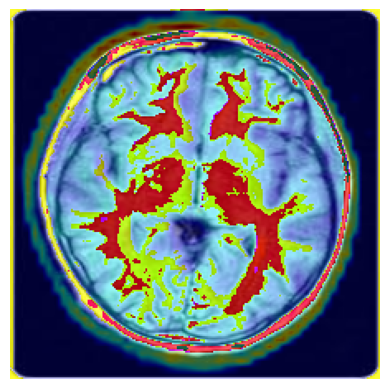

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Prepare image
img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
img_array = img / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 🔥 IMPORTANT FIX
dummy_input = np.zeros((1,224,224,3))
model(dummy_input)

# Create grad model (SAFE)
grad_model = tf.keras.models.Model(
    inputs=model.layers[0].input,
    outputs=[model.get_layer("last_conv").output, model.layers[-1].output]
)

# Gradient calculation
with tf.GradientTape() as tape:
    inputs = tf.cast(img_array, tf.float32)
    conv_outputs, predictions = grad_model(inputs)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)

# Heatmap
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = np.maximum(heatmap, 0)
if np.max(heatmap) != 0:
    heatmap /= np.max(heatmap)

# ✅ FIXED LINE
heatmap = cv2.resize(heatmap, (224,224))

# Color map
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay
original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224,224))

superimposed_img = heatmap * 0.4 + original_img

# Show
plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()